<a href="https://colab.research.google.com/github/Nasyaril/UTS_Citra_Digital/blob/main/PCD_No02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

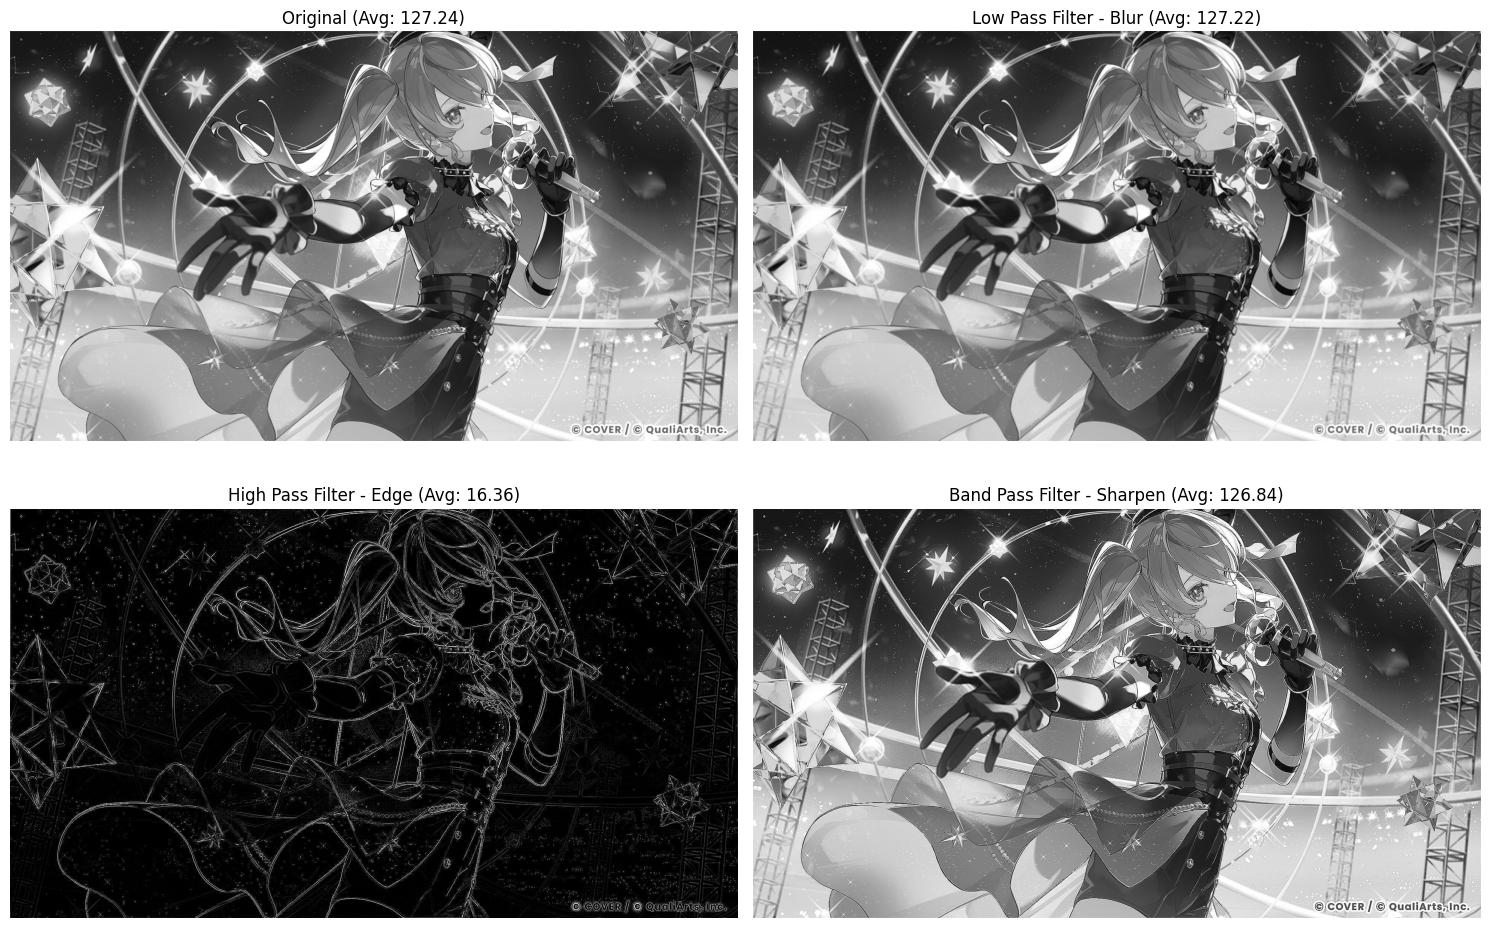

=== ANALISA NILAI RATA-RATA PIKSEL ===
Original : 127.24
LPF      : 127.22
HPF      : 16.36
BPF      : 126.84


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Membaca citra asli dalam mode grayscale
img_path = 'suisei.jpg'
f = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if f is None:
    print("Error: Citra tidak ditemukan. Pastikan file suisei.jpg sudah diupload.")
else:
    # 2. Definisikan Kernel berdasarkan Soal UTS
    kernel_LPF = np.ones((3,3), np.float32) / 9

    kernel_HPF = np.array([[-1, -1, -1],
                           [-1,  8, -1],
                           [-1, -1, -1]])

    kernel_BPF = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

    # 3. Terapkan Konvolusi menggunakan cv2.filter2D
    # ddepth = -1 agar output memiliki kedalaman/tipe data yang sama dengan input
    img_LPF = cv2.filter2D(f, -1, kernel_LPF)
    img_HPF = cv2.filter2D(f, -1, kernel_HPF)
    img_BPF = cv2.filter2D(f, -1, kernel_BPF)

    # 4. Hitung Rata-rata Nilai Piksel untuk bahan Analisa
    avg_orig = np.mean(f)
    avg_lpf  = np.mean(img_LPF)
    avg_hpf  = np.mean(img_HPF)
    avg_bpf  = np.mean(img_BPF)

    # 5. Visualisasi Hasil dalam 1 Figure berisi 4 Gambar
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(f, cmap='gray')
    plt.title(f'Original (Avg: {avg_orig:.2f})')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(img_LPF, cmap='gray')
    plt.title(f'Low Pass Filter - Blur (Avg: {avg_lpf:.2f})')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(img_HPF, cmap='gray')
    plt.title(f'High Pass Filter - Edge (Avg: {avg_hpf:.2f})')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(img_BPF, cmap='gray')
    plt.title(f'Band Pass Filter - Sharpen (Avg: {avg_bpf:.2f})')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    # Cetak perbandingan nilai rata-rata ke konsol
    print("=== ANALISA NILAI RATA-RATA PIKSEL ===")
    print(f"Original : {avg_orig:.2f}")
    print(f"LPF      : {avg_lpf:.2f}")
    print(f"HPF      : {avg_hpf:.2f}")
    print(f"BPF      : {avg_bpf:.2f}")